Goal: Build a small-scale cosmological simulation that generates overdensities and filamentary structure

Steps:
1. initialize particles on grid
2. apply Zel'dovich displacements
3. main loop
* CIC interpolation
* FFT to solve the Poisson equation (particle mesh, Barnes-Hut for speed & scaling later)
* Leapfrog integration to get the next step
* Periodic boundary conditions and Universe expansion factored in later (??)

In [18]:
## packages

import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
import os

STEP 1: PARTICLE INITIALIZATION ON GRID

(1000, 3)


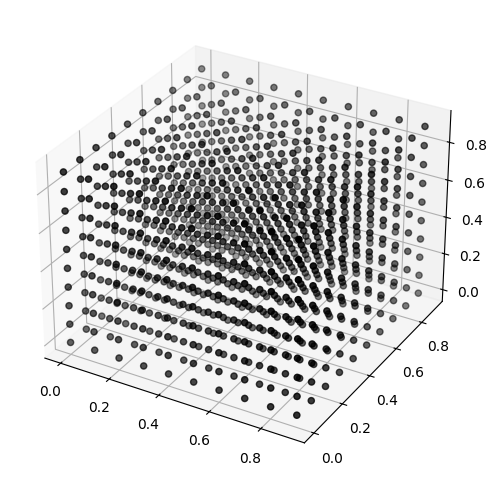

In [48]:
## creates a uniform 3D grid of particles, returning their positions as a (N, 3) array

def initialize_grid(n, box_size):
    
    coords = np.linspace(0, box_size, n, endpoint = False)
    X, Y, Z = np.meshgrid(coords, coords, coords, indexing = "ij")
    pos = np.vstack([X.ravel(), Y.ravel(), Z.ravel()]).T
    
    return pos

## visualization of particle initialization:

particle_locations = initialize_grid(10, 1.0)
print(particle_locations.shape)     ## shape should be (n^3, 3)

fig = plt.figure(figsize = (6, 6))
ax = fig.add_subplot(projection = '3d')

x = particle_locations[:, 0]
y = particle_locations[:, 1]
z = particle_locations[:, 2]

ax.scatter(x, y, z, color = "black")
plt.show()

In [49]:
## now that we have a function to initialize particles, we want to make those particle locations physically relevant
## we can do this by sampling from a density field

## generate a Gaussian random field using a toy power spectrum in Fourier space

def generate_gaussian_field(n, box_size, power_index = -3.0, epsilon = 1e-2):

    kfreq = np.fft.fftfreq(n, d = box_size / n) * (2 * np.pi)
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing = "ij")
    k = np.sqrt(kx**2 + ky**2 + kz**2)

    ## avoid division by zero:
    k[0, 0, 0] = 1.0

    ## toy power spectrum --> P(k) ~ k^-3
    Pk = (k + epsilon) ** power_index

    ## adding Gaussian noise
    noise = np.random.normal(size = (n, n, n)) + 1j * np.random.normal(size = (n, n, n))

    delta_k = noise * np.sqrt(Pk)
    delta_k[0, 0, 0] = 0.0       ## zero mean density

    delta = np.fft.ifftn(delta_k).real    ## inverse Fourier transform to get back to position-space

    return delta

## normalizing delta to a specific RMS amplitude, fixes small value problems

def normalize_density(delta, sigma = 0.1):
    
    delta = delta - np.mean(delta)
    delta /= np.std(delta)
    delta *= sigma
    
    return delta


#############################################################################

## visualization 1: slice of 3D density field

def plot_density_slice(delta, axis = 2, index = None):
    
    n = delta.shape[0]
    
    if index is None:
        index = n // 2  # middle slice

    if axis == 0:
        slice_2d = delta[index, :, :]
    elif axis == 1:
        slice_2d = delta[:, index, :]
    else:
        slice_2d = delta[:, :, index]

    plt.figure(figsize = (6, 6))
    plt.imshow(slice_2d, origin = 'lower', cmap = 'RdBu')
    plt.title("Visualization 1: Slice of 3D Density Field")
    plt.colorbar(label = 'Density contrast δ')
    plt.show()

#############################################################################

## visualization 2: PDF of density field (should be Gaussian)

def plot_density_histogram(delta):
    
    plt.hist(delta.flatten(), bins = 100, density = True)
    plt.title("Visualization 2: Density Field Distribution")
    plt.xlabel("δ")
    plt.ylabel("PDF")
    plt.show()

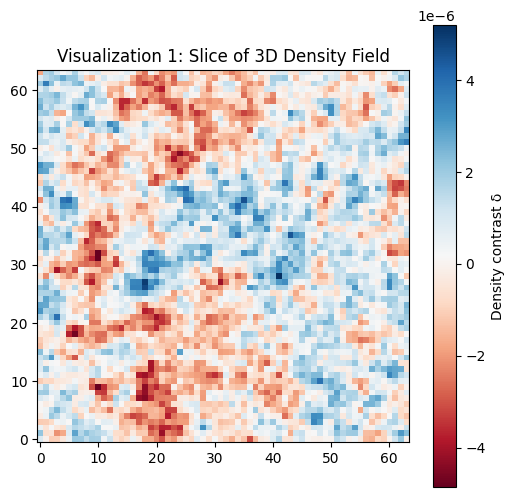

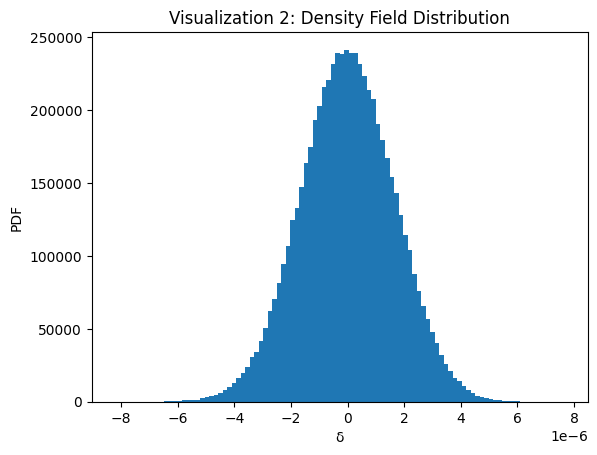

In [50]:
test = generate_gaussian_field(n = n, box_size = box_size)

plot_density_slice(test)
plot_density_histogram(test)

STEP 2: Apply Zel'dovich Displacements

In [51]:
## next step: create a set of functions that applies Zel'dovich displacements x(t) = q + b(t)*f(q)
## we can again start in Fourier space, then transform back to position space
## q = Lagrangian (initial) coordinate
## b(t) = time-scaling factor
## f(q) is the displacement field

def compute_displacement_field(delta, box_size):

    n = delta.shape[0]

    kfreq = np.fft.fftfreq(n, d = box_size / n) * (2 * np.pi)
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing = "ij")
    
    k2 = (kx**2 + ky**2 + kz**2)
    k2[0, 0, 0] = 1.0

    delta_k = np.fft.fftn(delta)

    factor = 1j / k2

    sx_k = factor * kx * delta_k
    sy_k = factor * ky * delta_k
    sz_k = factor * kz * delta_k

    sx = np.fft.ifftn(sx_k).real
    sy = np.fft.ifftn(sy_k).real
    sz = np.fft.ifftn(sz_k).real

    return sx, sy, sz

## D = growth factor
def apply_zeldovich_displacements(positions, sx, sy, sz, box_size, D):
    
    n = sx.shape[0]
    dx = box_size / n

    ## map particle positions to grid indices
    grid_idx = (positions / dx).astype(int) % n

    disp = np.zeros_like(positions)

    disp[:, 0] = sx[grid_idx[:, 0], grid_idx[:, 1], grid_idx[:, 2]]
    disp[:, 1] = sy[grid_idx[:, 0], grid_idx[:, 1], grid_idx[:, 2]]
    disp[:, 2] = sz[grid_idx[:, 0], grid_idx[:, 1], grid_idx[:, 2]]


    pos_final = positions + D * disp
    pos_final %= box_size  # periodic boundary conditions
    
    return pos_final, disp

In [52]:
## computing initial velocity field

def compute_velocities(disp, growth_rate):

    # IMPORTANT: no extra scaling factors elsewhere
    vel = growth_rate * disp

    return vel

In [53]:
## ONE FUNCTION TO GENERATE INITIAL CONDITIONS:

In [54]:
## function to generate initial conditions:

def run_initial_conditions(n, box_size, sigma, D, growth_rate):

    # grid
    pos = initialize_grid(n, box_size)

    # density field
    delta = generate_gaussian_field(n, box_size)
    delta = normalize_density(delta, sigma = sigma)

    # displacement field
    sx, sy, sz = compute_displacement_field(delta, box_size)

    # apply displacement
    pos_final, disp = apply_zeldovich_displacements(pos, sx, sy, sz, box_size, D = D)

    # velocities (CONSISTENT, no double scaling)
    vel = compute_velocities(disp, growth_rate = growth_rate)

    return pos, pos_final, vel, delta, disp

In [55]:
pos_initial, pos_final, vel, delta, disp = run_initial_conditions(n, box_size, sigma, D, growth_rate)

In [56]:
## visualizations of initial conditions:

## initial versus dispersed particles
def plot_initial_vs_displaced(pos_initial, pos_final, box_size):
    fig, ax = plt.subplots(1, 2, figsize = (10, 5))

    ax[0].scatter(pos_initial[:,0], pos_initial[:,1], s = 1)
    ax[0].set_title("Initial Lagrangian grid")
    ax[0].set_xlim(0, box_size)
    ax[0].set_ylim(0, box_size)

    ax[1].scatter(pos_final[:,0], pos_final[:,1], s=1)
    ax[1].set_title("Zel'dovich displaced field")
    ax[1].set_xlim(0, box_size)
    ax[1].set_ylim(0, box_size)

    plt.tight_layout()
    plt.show()

## flow of particles
def plot_velocity_field(pos_initial, vel, box_size, step = 2):

    plt.figure(figsize = (6,6))

    plt.quiver(pos_initial[::step, 0], pos_initial[::step, 1], vel[::step, 0], vel[::step, 1], scale = 0.8)

    plt.title("Initial velocity field (Zel'dovich)")
    plt.xlim(0, box_size)
    plt.ylim(0, box_size)
    plt.show()

## velocity magnitude map
def plot_velocity_magnitude(vel):

    vmag = np.linalg.norm(vel, axis = 1)

    plt.figure(figsize = (5, 4))
    plt.hist(vmag, bins = 80)
    plt.title("Velocity magnitude distribution")
    plt.xlabel("|v|")
    plt.ylabel("count")
    plt.show()

    print("vmin:", vmag.min(), "vmax:", vmag.max(), "mean:", vmag.mean())

## displacement magnitude map
def plot_displacement_magnitude(disp, n, box_size):

    mag = np.linalg.norm(disp, axis = 1)
    grid = mag.reshape(n, n, n)

    slice2d = grid[:, :, n//2]

    plt.figure(figsize = (5,5))
    plt.imshow(slice2d, origin = 'lower', cmap = 'viridis')
    plt.colorbar(label = "|displacement|")
    plt.title("Displacement magnitude slice")
    plt.show()

def velocity_alignment_check(disp, vel):

    d = disp / (np.linalg.norm(disp, axis = 1, keepdims = True) + 1e-12)
    v = vel / (np.linalg.norm(vel, axis = 1, keepdims = True) + 1e-12)

    cos_angle = np.sum(d * v, axis = 1)

    print("mean alignment (should be ~1):", np.mean(cos_angle))


def visualize_initial_conditions(pos_initial, pos_final, vel, disp, n, box_size):

    plot_initial_vs_displaced(pos_initial, pos_final, box_size)
    plot_velocity_field(pos_initial, vel, box_size)
    plot_velocity_magnitude(vel)
    plot_displacement_magnitude(disp, n, box_size)
    velocity_alignment_check(disp, vel)

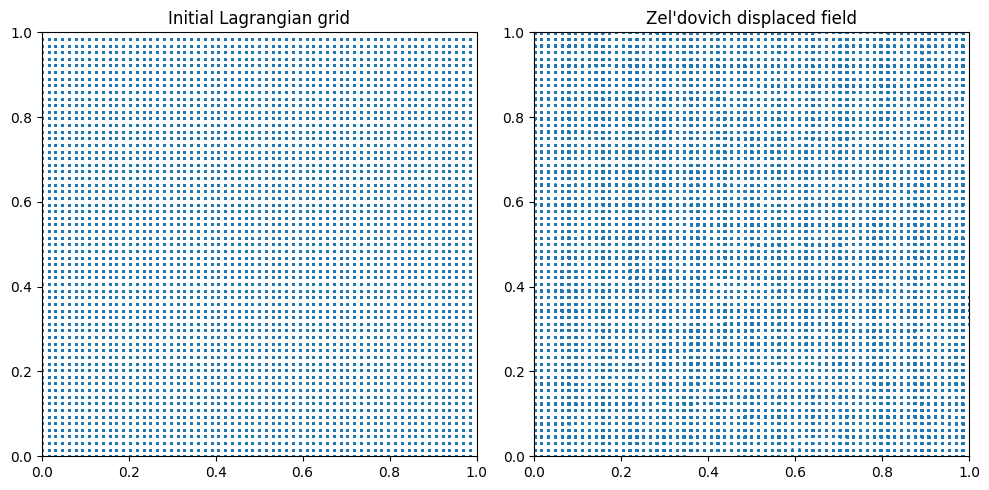

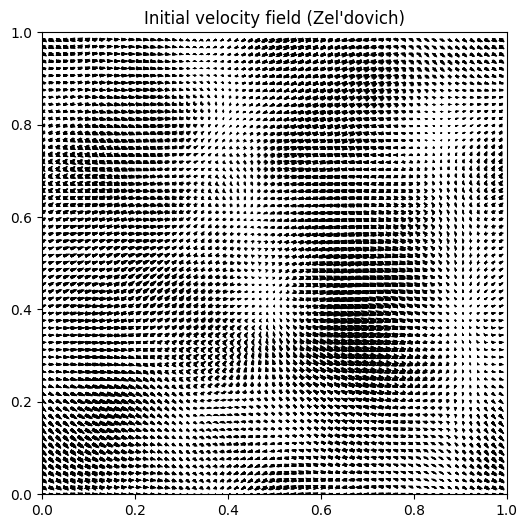

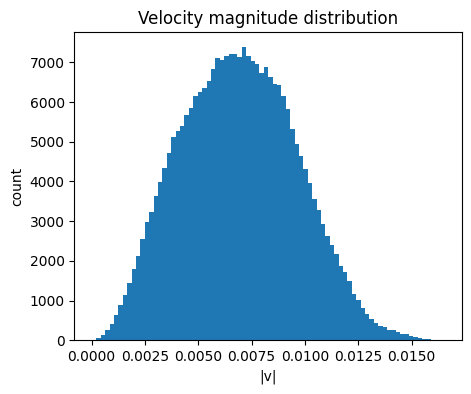

vmin: 2.4132502042099105e-05 vmax: 0.016527341533037886 mean: 0.006921671512705994


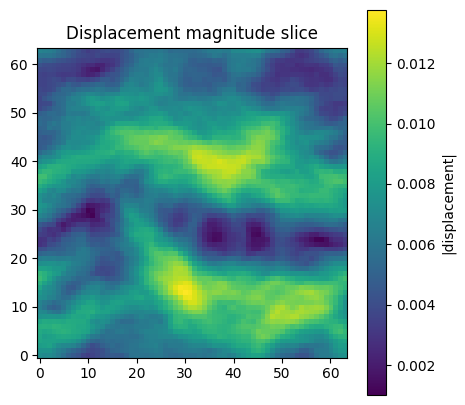

mean alignment (should be ~1): 0.9999999996380903


In [58]:
visualize_initial_conditions(pos_initial, pos_final, vel, disp, n, box_size)

STEP 3: MAIN LOOP, IMPLEMENTING GRAVITY SOLVER

In [63]:
## CIC (cloud-in-cell) density assignment (converts particles to grid density) is:
## a way to turn discrete particles into a smooth, mass-conserving density field by
## linearly weighting each particle across the 8 surrounding grid cells based on distance.
## instead of dumping a particle into one cell, we “spread its mass across the 8 surrounding grid cells proportionally to distance”
## each particle is a "cloud," and the grid cells sample how much cloud overlaps them
## each grid corner gets a weight based on distance in x, y, z.

def cic_density(pos, n, box_size):

    rho = np.zeros((n, n, n), dtype = np.float64)

    dx = box_size / n

    # convert positions to grid units
    x = pos / dx  # shape (N, 3)

    i = np.floor(x).astype(int)
    f = x - i     # fractional position inside cell

    # periodic wrapping of base indices
    i0 = i % n
    i1 = (i + 1) % n

    # unpack fractional weights
    fx, fy, fz = f[:, 0], f[:, 1], f[:, 2]

    wx0 = 1.0 - fx
    wy0 = 1.0 - fy
    wz0 = 1.0 - fz

    wx1 = fx
    wy1 = fy
    wz1 = fz

    # all 8 contributions (vectorized)
    for dx_i, wx in [(0, wx0), (1, wx1)]:
        for dy_i, wy in [(0, wy0), (1, wy1)]:
            for dz_i, wz in [(0, wz0), (1, wz1)]:

                w = wx * wy * wz

                ix = (i0[:, 0] + dx_i) % n
                iy = (i0[:, 1] + dy_i) % n
                iz = (i0[:, 2] + dz_i) % n

                np.add.at(rho, (ix, iy, iz), w)

    # normalize to mean density = 1
    rho /= np.mean(rho)

    return rho


## now we want to solve the Poisson equation

def poisson_solver(rho, box_size, G = 1.0):

    n = rho.shape[0]

    kfreq = np.fft.fftfreq(n, d = box_size/n) * (2*np.pi)
    kx, ky, kz = np.meshgrid(kfreq, kfreq, kfreq, indexing = "ij")

    k2 = kx**2 + ky**2 + kz**2
    k2[0, 0, 0] = 1.0

    rho_k = np.fft.fftn(rho - 1.0)

    ## poisson equation
    phi_k = -4*np.pi*G * rho_k / k2
    phi_k[0, 0, 0] = 0.0

    phi = np.fft.ifftn(phi_k).real

    return phi, phi_k, kx, ky, kz


## using "force equals minus the gradient of the potential," calculate the force:

def compute_gravitational_force(phi_k, kx, ky, kz):

    fx_k = 1j * kx * phi_k
    fy_k = 1j * ky * phi_k
    fz_k = 1j * kz * phi_k

    fx = np.fft.ifftn(fx_k).real
    fy = np.fft.ifftn(fy_k).real
    fz = np.fft.ifftn(fz_k).real

    return fx, fy, fz


## interpolate back to particles using an inverse mapping of CIC

def interpolate_force(pos, fx, fy, fz, box_size):

    n = fx.shape[0]
    dx = box_size / n

    x = pos / dx

    i = np.floor(x).astype(int)
    f = x - i

    i0 = i % n
    i1 = (i + 1) % n

    fx_p = np.zeros(len(pos))
    fy_p = np.zeros(len(pos))
    fz_p = np.zeros(len(pos))

    wx0 = 1 - f[:, 0]; wx1 = f[:, 0]
    wy0 = 1 - f[:, 1]; wy1 = f[:, 1]
    wz0 = 1 - f[:, 2]; wz1 = f[:, 2]

    for dx_i, wx in [(0, wx0),(1, wx1)]:
        for dy_i, wy in [(0, wy0),(1, wy1)]:
            for dz_i, wz in [(0, wz0),(1, wz1)]:

                w = wx * wy * wz

                ix = (i0[:, 0] + dx_i) % n
                iy = (i0[:, 1] + dy_i) % n
                iz = (i0[:, 2] + dz_i) % n

                fx_p += w * fx[ix, iy, iz]
                fy_p += w * fy[ix, iy, iz]
                fz_p += w * fz[ix, iy, iz]

    return np.stack([fx_p, fy_p, fz_p], axis = 1)


## leapfrog integrator to update positions, etc

def leapfrog(pos, vel, force, dt, box_size):

    vel_half = vel + 0.5 * dt * force
    pos_new = pos + dt * vel_half

    # periodic boundaries
    pos_new %= box_size

    return pos_new, vel_half


## all of the above functions combined into one that updates the timestep

def pm_step(pos, vel, n, box_size, dt):

    ## compute CIC density
    rho = cic_density(pos, n, box_size)

    # 2. potential
    phi, phi_k, kx, ky, kz = poisson_solver(rho, box_size)

    # 3. force field
    fx, fy, fz = compute_gravitational_force(phi_k, kx, ky, kz)

    # 4. interpolate force
    force = interpolate_force(pos, fx, fy, fz, box_size)

    # 5. update particles
    pos, vel = leapfrog(pos, vel, force, dt, box_size)

    return pos, vel

Now that we have this pipeline, let's test it out!!

In [64]:
## run and record simulation
def run_and_record(pos, vel, n, box_size, dt, nsteps):

    density_frames = []
    particle_frames = []

    for step in range(nsteps):

        pos, vel = pm_step(pos, vel, n, box_size, dt)

        rho = cic_density(pos, n, box_size)

        density_frames.append(rho.copy())
        particle_frames.append(pos.copy())

    return density_frames, particle_frames


## save the density frames to make a GIF later
def save_density_frames(frames, outdir = "density_frames"):

    os.makedirs(outdir, exist_ok = True)

    for i, rho in enumerate(frames):

        mid = rho.shape[2] // 2
        slice2d = np.log(rho[:, :, mid] + 1e-3)

        plt.figure(figsize = (4,4))
        plt.imshow(slice2d, origin = "lower", cmap = "inferno")

        plt.axis("off")
        plt.title(f"step {i}")

        plt.savefig(f"{outdir}/frame_{i:04d}.png", bbox_inches = "tight", pad_inches = 0.1, dpi = 100)

        plt.close()

## save the particle PNG frames to make a GIF later
def save_particle_frames(frames, box_size, outdir = "particle_frames"):

    os.makedirs(outdir, exist_ok = True)

    for i, pos in enumerate(frames):

        plt.figure(figsize=(4,4))
        plt.scatter(pos[:,0], pos[:,1], s = 1)

        plt.xlim(0, box_size)
        plt.ylim(0, box_size)

        plt.axis("off")
        plt.title(f"step {i}")

        plt.savefig(f"{outdir}/frame_{i:04d}.png", bbox_inches = "tight", pad_inches = 0.1, dpi = 100)

        plt.close()


## make GIF from folders
def make_gif(folder, output = "output.gif", fps = 5):

    files = sorted([
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.endswith(".png")
    ])

    images = [imageio.imread(f) for f in files]

    imageio.mimsave(output, images, fps = fps)

    print("Saved:", output)


## pipeline wrapper 
def run_full_pipeline(pos, vel, n, box_size, dt, nsteps):

    # 1. run simulation
    density_frames, particle_frames = run_and_record(pos, vel, n, box_size, dt, nsteps)

    # 2. save PNG frames
    save_density_frames(density_frames)
    save_particle_frames(particle_frames, box_size)

    # 3. build GIFs
    make_gif("density_frames", "density.gif", fps = 5)
    make_gif("particle_frames", "particles.gif", fps = 5)

    print("Done.")

In [68]:
## global parameters
n = 32
box_size = 1.0
G = 1.0
dt = 0.001
nsteps = 1000
sigma = 0.1
D = 0.1
growth_rate = 1.0

In [ ]:
## pos_initial, pos_final, vel, delta, disp are the variables output by the initial conditions function, so those are what we have to work with now
run_full_pipeline(pos = pos_final, vel = vel, n = n, box_size = box_size, dt = dt, nsteps = nsteps)